# HR Analytics – Employee Attrition Prediction System

## Problem Statement
Organizations invest significant time and cost in hiring, training, and retaining employees. Despite these efforts, many companies face high employee attrition, which impacts productivity and increases operational costs. This project uses HR Analytics to identify the key factors contributing to employee attrition and to derive insights that can help improve employee retention strategies.

### 01 Data Cleaning

- <b> IMPORT LIBRARIES  </b>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows",100)
plt.style.use("ggplot")

-  <b>LOAD DATASET </b>

In [2]:
df = pd.read_csv("HR-Employee-Attrition.csv")
print(df.head())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   EnvironmentSatisfaction  Gender  HourlyRate  JobInvolvement  JobLevel  

-  <b>BASIC INFORMATION </b>

In [3]:
print("="*60)
print("Dataset Shape")
print("="*60)
print(df.shape)

print("\n")
print("="*60)
print("Columns")
print("="*60)
print(df.columns.tolist())

print("\n")
print("="*60)
print("Data Types")
print("="*60)
print(df.dtypes)

print("\n")
print("="*60)
print("Memory Usage")
print("="*60)
print(df.memory_usage(deep=True))

Dataset Shape
(1470, 35)


Columns
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


Data Types
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber    

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [5]:
numerical_cols = df.select_dtypes(include=['int64','float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns
print("Numerical Columns:",len(numerical_cols))
print(numerical_cols)
print("\nCategorical Columns:",len(categorical_cols))
print(categorical_cols)
# print(df.describe())
# df.describe(include="object")

Numerical Columns: 26
Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

Categorical Columns: 9
Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')


-  <b> MISSING VALUES </b>

In [6]:
missing_values = df.isnull().sum()
print(missing_values)

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

- <b>Unique Values</b>

In [7]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Age: 43 unique values
Attrition: 2 unique values
BusinessTravel: 3 unique values
DailyRate: 886 unique values
Department: 3 unique values
DistanceFromHome: 29 unique values
Education: 5 unique values
EducationField: 6 unique values
EmployeeCount: 1 unique values
EmployeeNumber: 1470 unique values
EnvironmentSatisfaction: 4 unique values
Gender: 2 unique values
HourlyRate: 71 unique values
JobInvolvement: 4 unique values
JobLevel: 5 unique values
JobRole: 9 unique values
JobSatisfaction: 4 unique values
MaritalStatus: 3 unique values
MonthlyIncome: 1349 unique values
MonthlyRate: 1427 unique values
NumCompaniesWorked: 10 unique values
Over18: 1 unique values
OverTime: 2 unique values
PercentSalaryHike: 15 unique values
PerformanceRating: 2 unique values
RelationshipSatisfaction: 4 unique values
StandardHours: 1 unique values
StockOptionLevel: 4 unique values
TotalWorkingYears: 40 unique values
TrainingTimesLastYear: 7 unique values
WorkLifeBalance: 4 unique values
YearsAtCompany: 37 uni

-  <b>Fill numerical columns </b> 

In [8]:
numerical_cols = df.select_dtypes(include=['int64','float64']).columns

for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

-  <b> Fill categorical columns </b> 

In [9]:
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols: 
    df[col].fillna(df[col].mode()[0], inplace=True)

-  <b>DUPLICATES </b>

In [10]:
print("Duplicates :", df.duplicated().sum())
df.drop_duplicates(inplace=True)

Duplicates : 0


- <b>Descriptive Statistics</b>

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [12]:
df.describe(include='object').T

,count,unique,top,freq
Attrition,1470,2,No,1233
BusinessTravel,1470,3,Travel_Rarely,1043
Department,1470,3,Research & Development,961
EducationField,1470,6,Life Sciences,606
Gender,1470,2,Male,882
JobRole,1470,9,Sales Executive,326
MaritalStatus,1470,3,Married,673
Over18,1470,1,Y,1470
OverTime,1470,2,No,1054


-  <b> CHECK DATA TYPES</b>

In [13]:
print(df.dtypes)

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

-  <b> SAVE CLEAN DATA </b>

In [14]:
df.to_csv( "HR-Employee-Attrition.csv", index=False)
print("Dataset Saved Successfully")

Dataset Saved Successfully


### 02 EDA

In [15]:
df = pd.read_csv("HR-Employee-Attrition.csv")
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,3,Male,41,4,2,Laboratory Technician,4,Married,2571,12290,4,Y,No,17,3,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,4,Male,42,2,3,Healthcare Representative,1,Married,9991,21457,4,Y,No,15,3,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,2,Male,87,4,2,Manufacturing Director,2,Married,6142,5174,1,Y,Yes,20,4,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,4,Male,63,2,2,Sales Executive,2,Married,5390,13243,2,Y,No,14,3,4,80,0,17,3,2,9,6,0,8


- <b> Attrition Distribution</b>

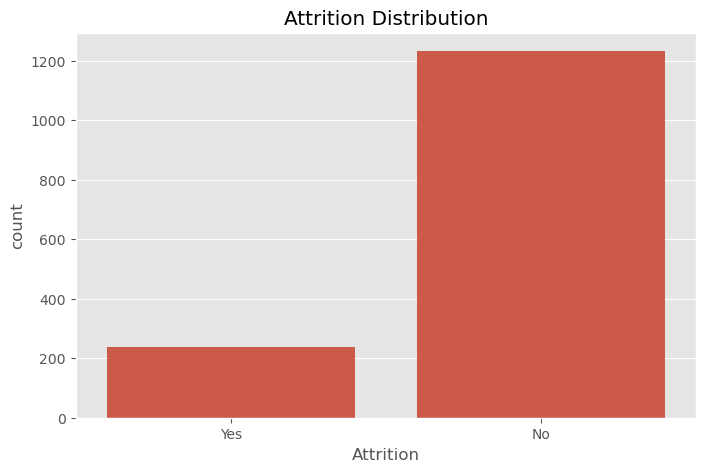

In [16]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Attrition')

plt.title("Attrition Distribution")
plt.show()

-  <b> Department Analysis </b>

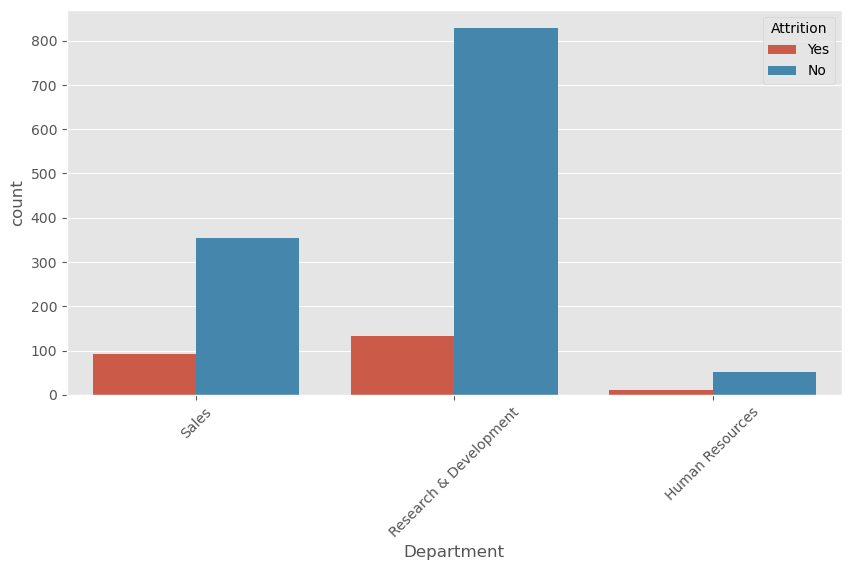

In [17]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Department', hue='Attrition')

plt.xticks(rotation=45)
plt.show()

-  <b> Job Role Analysis</b>

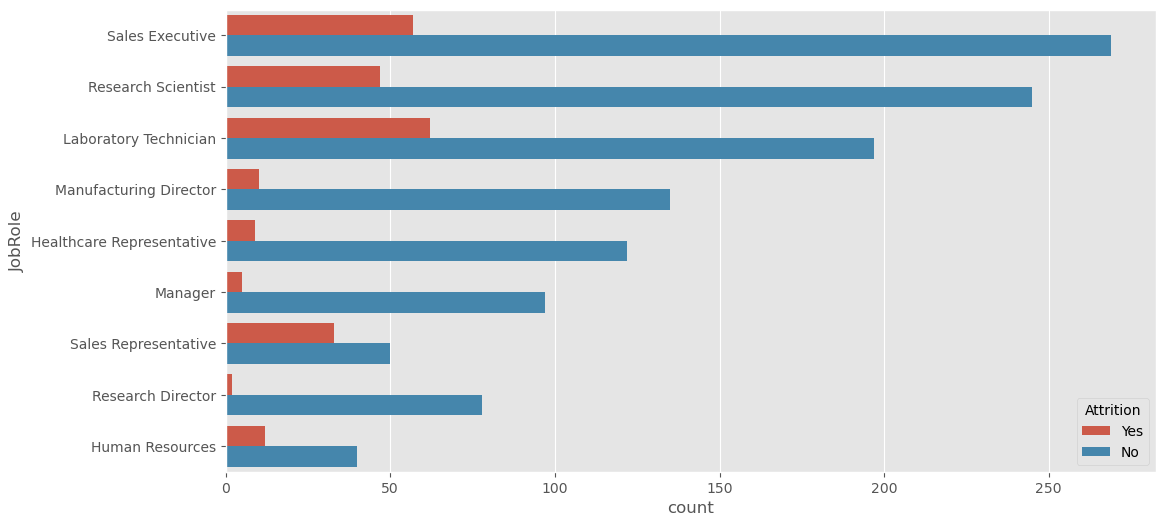

In [18]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, y='JobRole', hue='Attrition')
plt.show()

- <b> Overtime Analysis</b> 

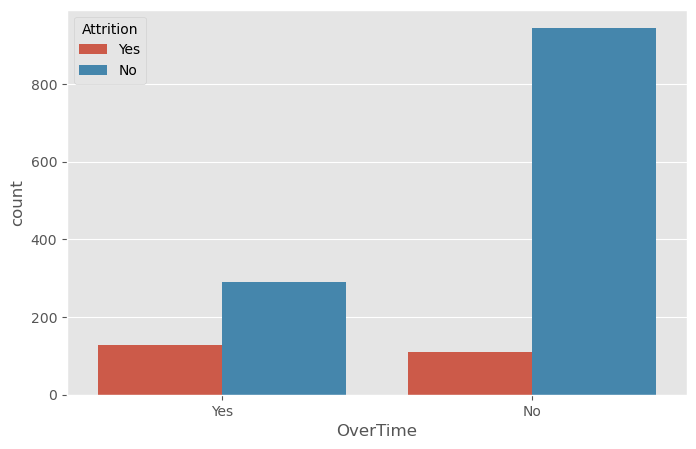

In [19]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='OverTime', hue='Attrition')
plt.show(
)

-  <b> Salary Analysis </b>

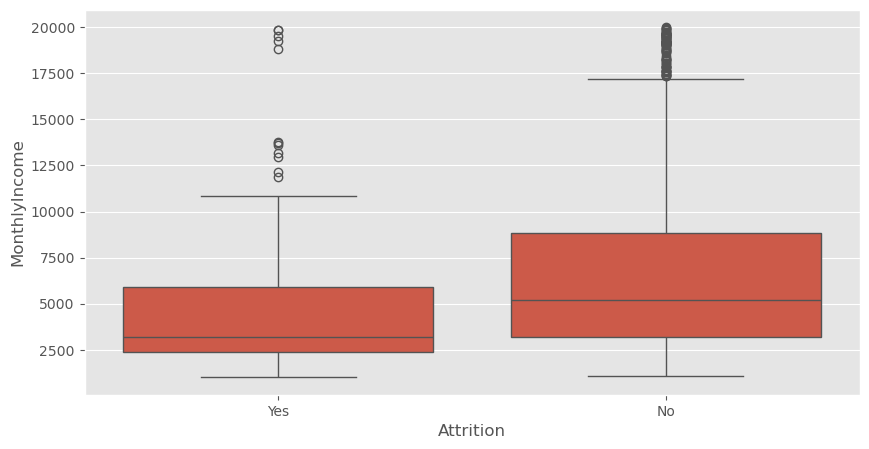

In [20]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome')
plt.show()

- <b>Age vs Attrition

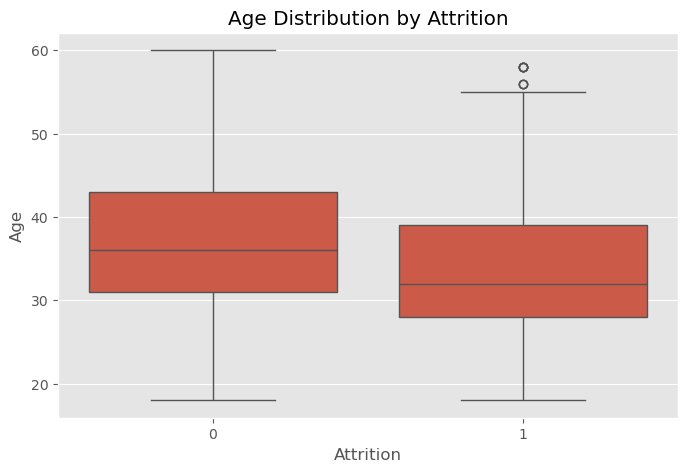

In [54]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Attrition', y='Age', data=df)
plt.title("Age Distribution by Attrition")
plt.show()

- <b> Years at Company vs Attrition

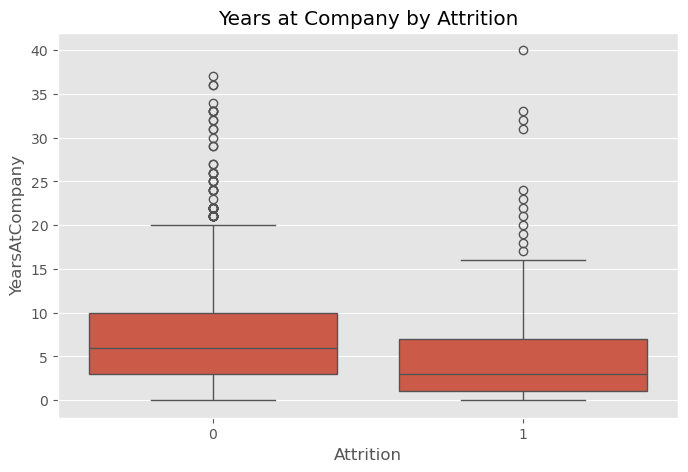

In [55]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Attrition', y='YearsAtCompany', data=df)
plt.title("Years at Company by Attrition")
plt.show()

- <b>Work Life Balance vs Attrition

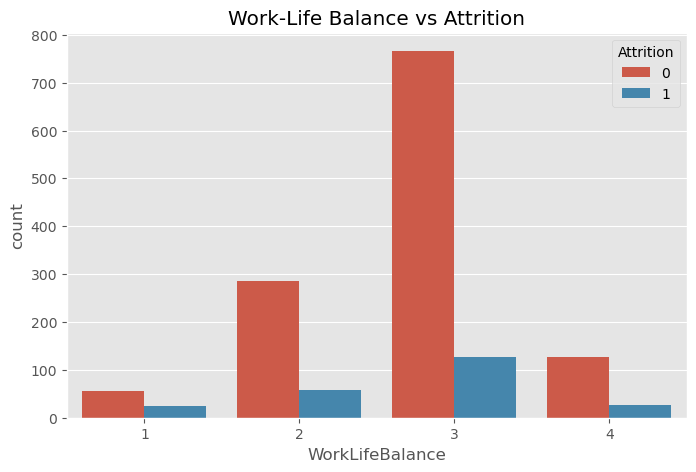

In [56]:
plt.figure(figsize=(8,5))
sns.countplot(x='WorkLifeBalance', hue='Attrition', data=df)
plt.title("Work-Life Balance vs Attrition")
plt.show()

- <b>Job Satisfaction vs Attrition

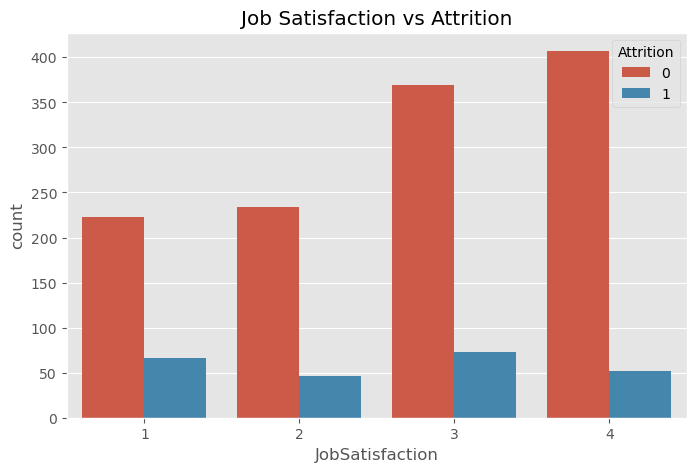

In [57]:
plt.figure(figsize=(8,5))
sns.countplot(x='JobSatisfaction', hue='Attrition', data=df)
plt.title("Job Satisfaction vs Attrition")
plt.show()

In [21]:
df=pd.read_csv('HR-Employee-Attrition.csv')
print(df)

      Age Attrition     BusinessTravel  DailyRate              Department  \
0      41       Yes      Travel_Rarely       1102                   Sales   
1      49        No  Travel_Frequently        279  Research & Development   
2      37       Yes      Travel_Rarely       1373  Research & Development   
3      33        No  Travel_Frequently       1392  Research & Development   
4      27        No      Travel_Rarely        591  Research & Development   
...   ...       ...                ...        ...                     ...   
1465   36        No  Travel_Frequently        884  Research & Development   
1466   39        No      Travel_Rarely        613  Research & Development   
1467   27        No      Travel_Rarely        155  Research & Development   
1468   49        No  Travel_Frequently       1023                   Sales   
1469   34        No      Travel_Rarely        628  Research & Development   

      DistanceFromHome  Education EducationField  EmployeeCount  \
0       

- <b>Encoding categorical data </b>

In [22]:
# Using Label Encoder on target variable
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Attrition"] = le.fit_transform(df["Attrition"])
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [23]:
df.drop(["EmployeeCount", "EmployeeNumber", "Over18", "StandardHours"], axis=1, inplace=True)

In [24]:
df.shape

(1470, 31)

In [25]:
# Ordinal Encoding for ordinal variables
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder()
def ordinal_encode(df, column):
    df[column] = oe.fit_transform(df[column])
    return df

oe_col = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
df=ordinal_encode(df, oe_col)
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2.0,1102,2.0,1,2,1.0,2,0.0,94,3,2,7.0,4,2.0,5993,19479,8,1.0,11,3,1,0,8,0,1,6,4,0,5
1,49,0,1.0,279,1.0,8,1,1.0,3,1.0,61,2,2,6.0,2,1.0,5130,24907,1,0.0,23,4,4,1,10,3,3,10,7,1,7
2,37,1,2.0,1373,1.0,2,2,4.0,4,1.0,92,2,1,2.0,3,2.0,2090,2396,6,1.0,15,3,2,0,7,3,3,0,0,0,0
3,33,0,1.0,1392,1.0,3,4,1.0,4,0.0,56,3,1,6.0,3,1.0,2909,23159,1,1.0,11,3,3,0,8,3,3,8,7,3,0
4,27,0,2.0,591,1.0,2,1,3.0,1,1.0,40,3,1,2.0,2,1.0,3468,16632,9,0.0,12,3,4,1,6,3,3,2,2,2,2


- <b> Features containing outliers  </b>

In [26]:
from scipy.stats import zscore
z = np.abs(zscore(df))
threshold = 3
df1 = df[(z<3).all(axis = 1)]

print ("Shape of the dataframe before removing outliers: ", df.shape)
print ("Shape of the dataframe after removing outliers: ", df1.shape)
print ("Percentage of data loss post outlier removal: ", (df.shape[0]-df1.shape[0])/df.shape[0]*100)

df=df1.copy() # reassigning the changed dataframe name to our original dataframe name

Shape of the dataframe before removing outliers:  (1470, 31)
Shape of the dataframe after removing outliers:  (1387, 31)
Percentage of data loss post outlier removal:  5.646258503401361


- <b>Data Loss </b>

In [27]:
print("\033[1m"+'Percentage Data Loss :'+"\033[0m",((1470-1387)/1470)*100,'%')

Percentage Data Loss : 5.646258503401361 %


#### Feature selection and Engineering
- <b>Skewness of features</b>

In [28]:
df.skew()

Age                         0.472280
Attrition                   1.805983
BusinessTravel             -1.426774
DailyRate                  -0.017078
Department                  0.183919
DistanceFromHome            0.954752
Education                  -0.289024
EducationField              0.544868
EnvironmentSatisfaction    -0.325285
Gender                     -0.417296
HourlyRate                 -0.030481
JobInvolvement             -0.501401
JobLevel                    1.126075
JobRole                    -0.386843
JobSatisfaction            -0.345612
MaritalStatus              -0.160952
MonthlyIncome               1.544770
MonthlyRate                 0.030596
NumCompaniesWorked          1.037715
OverTime                    0.954751
PercentSalaryHike           0.800592
PerformanceRating           1.931566
RelationshipSatisfaction   -0.295686
StockOptionLevel            0.962332
TotalWorkingYears           1.034487
TrainingTimesLastYear       0.577614
WorkLifeBalance            -0.557100
Y

In [29]:
# Splitting data in target and dependent feature
X = df.drop(['Attrition'], axis =1)
Y = df['Attrition']

- <b>Transforming  skew data using power transform</b>

In [30]:
from sklearn.preprocessing import power_transform
x = df
df = power_transform(x)
df = pd.DataFrame(df, columns=x.columns)
df.skew()

Age                        -0.004079
Attrition                   1.805983
BusinessTravel             -0.960583
DailyRate                  -0.199742
Department                  0.015095
DistanceFromHome           -0.008149
Education                  -0.103747
EducationField             -0.008642
EnvironmentSatisfaction    -0.205472
Gender                     -0.417296
HourlyRate                 -0.105678
JobInvolvement             -0.018801
JobLevel                    0.110769
JobRole                    -0.337641
JobSatisfaction            -0.217730
MaritalStatus              -0.158253
MonthlyIncome               0.027700
MonthlyRate                -0.176560
NumCompaniesWorked          0.016175
OverTime                    0.954751
PercentSalaryHike           0.112128
PerformanceRating           0.000000
RelationshipSatisfaction   -0.191406
StockOptionLevel            0.089929
TotalWorkingYears          -0.009666
TrainingTimesLastYear       0.057949
WorkLifeBalance            -0.011133
Y

-  <b>Correlation Heatmap</b>

In [31]:
df.corr()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000,-0.177212,0.019607,0.019864,-0.036344,-0.025855,0.215520,-0.037564,0.013967,-0.037163,0.026203,0.032323,0.442350,-0.116758,0.010038,-0.117182,0.452513,0.020538,0.340022,0.028332,0.010488,-0.002365,0.037296,0.089449,0.652405,-0.014951,-0.016180,0.207538,0.145404,0.114162,0.142446
Attrition,-0.177212,1.000000,-0.036528,-0.056354,0.060869,0.080979,-0.033935,0.013970,-0.108704,0.036252,-0.001049,-0.129655,-0.196464,0.065426,-0.114064,0.161038,-0.207280,0.014146,0.047508,0.257237,-0.017523,0.010781,-0.050918,-0.175081,-0.220878,-0.059071,-0.051039,-0.201954,-0.187047,-0.050986,-0.186821
BusinessTravel,0.019607,-0.036528,1.000000,-0.001984,-0.003560,-0.007041,-0.006468,0.034658,0.004183,-0.011439,0.026364,0.018230,0.003401,-0.002615,-0.033026,0.010108,0.030793,-0.008138,0.034013,0.010934,-0.019175,-0.021061,-0.036165,-0.006092,0.027298,0.006192,-0.017977,-0.024021,-0.035610,-0.033148,-0.032665
DailyRate,0.019864,-0.056354,-0.001984,1.000000,-0.003546,-0.006034,-0.017504,0.040993,0.034324,-0.003271,0.015156,0.041841,0.015931,-0.013156,0.044460,-0.076058,0.029944,-0.032890,0.034923,0.020045,0.029183,0.000687,0.005771,0.049415,0.042750,0.005118,-0.046550,0.005391,0.022143,-0.035448,0.005908
Department,-0.036344,0.060869,-0.003560,-0.003546,1.000000,0.037834,0.012780,0.082525,-0.013867,-0.030950,-0.000623,-0.025121,0.200829,0.681597,0.030615,0.052696,0.152234,0.023941,-0.033131,0.015121,-0.013541,-0.038429,-0.037572,-0.000630,-0.006833,0.039938,0.017807,0.025457,0.057817,0.017699,0.024241
DistanceFromHome,-0.025855,0.080979,-0.007041,-0.006034,0.037834,1.000000,0.002714,0.021074,-0.013409,0.010557,0.015607,0.038096,0.024038,0.010044,-0.020165,-0.027285,0.000545,0.047736,-0.010318,0.036524,0.034946,0.013212,0.009379,0.027082,-0.012129,-0.015334,-0.030011,0.006570,0.013091,-0.003873,-0.002310
Education,0.215520,-0.033935,-0.006468,-0.017504,0.012780,0.002714,1.000000,-0.038405,-0.026095,-0.017807,0.011105,0.042166,0.103834,0.016548,-0.005640,-0.012237,0.112084,-0.018874,0.136101,-0.015248,-0.002095,-0.023157,-0.004863,0.025621,0.150720,-0.023039,0.010164,0.037921,0.051072,0.016076,0.026651
EducationField,-0.037564,0.013970,0.034658,0.040993,0.082525,0.021074,-0.038405,1.000000,0.042609,0.005059,-0.004372,-0.007969,-0.026676,0.050693,-0.050693,0.013433,-0.020033,-0.027785,-0.010403,0.010335,0.000812,-0.001393,-0.018254,-0.012936,-0.001827,0.054321,0.034788,0.004483,0.004372,0.023062,0.028189
EnvironmentSatisfaction,0.013967,-0.108704,0.004183,0.034324,-0.013867,-0.013409,-0.026095,0.042609,1.000000,-0.014940,-0.042512,-0.020953,0.010615,-0.022464,-0.009553,-0.012356,-0.011976,0.036843,0.011203,0.058274,-0.027743,-0.024853,0.016892,0.024345,-0.013356,-0.018350,0.030422,0.012338,0.029218,0.038031,0.006417
Gender,-0.037163,0.036252,-0.011439,-0.003271,-0.030950,0.010557,-0.017807,0.005059,-0.014940,1.000000,0.005618,0.014878,-0.058378,-0.036436,0.038130,-0.056779,-0.052340,-0.047240,-0.033345,-0.051558,0.010984,-0.010757,0.041439,0.024390,-0.049776,-0.039213,0.002726,-0.046018,-0.028101,-0.016131,-0.027972


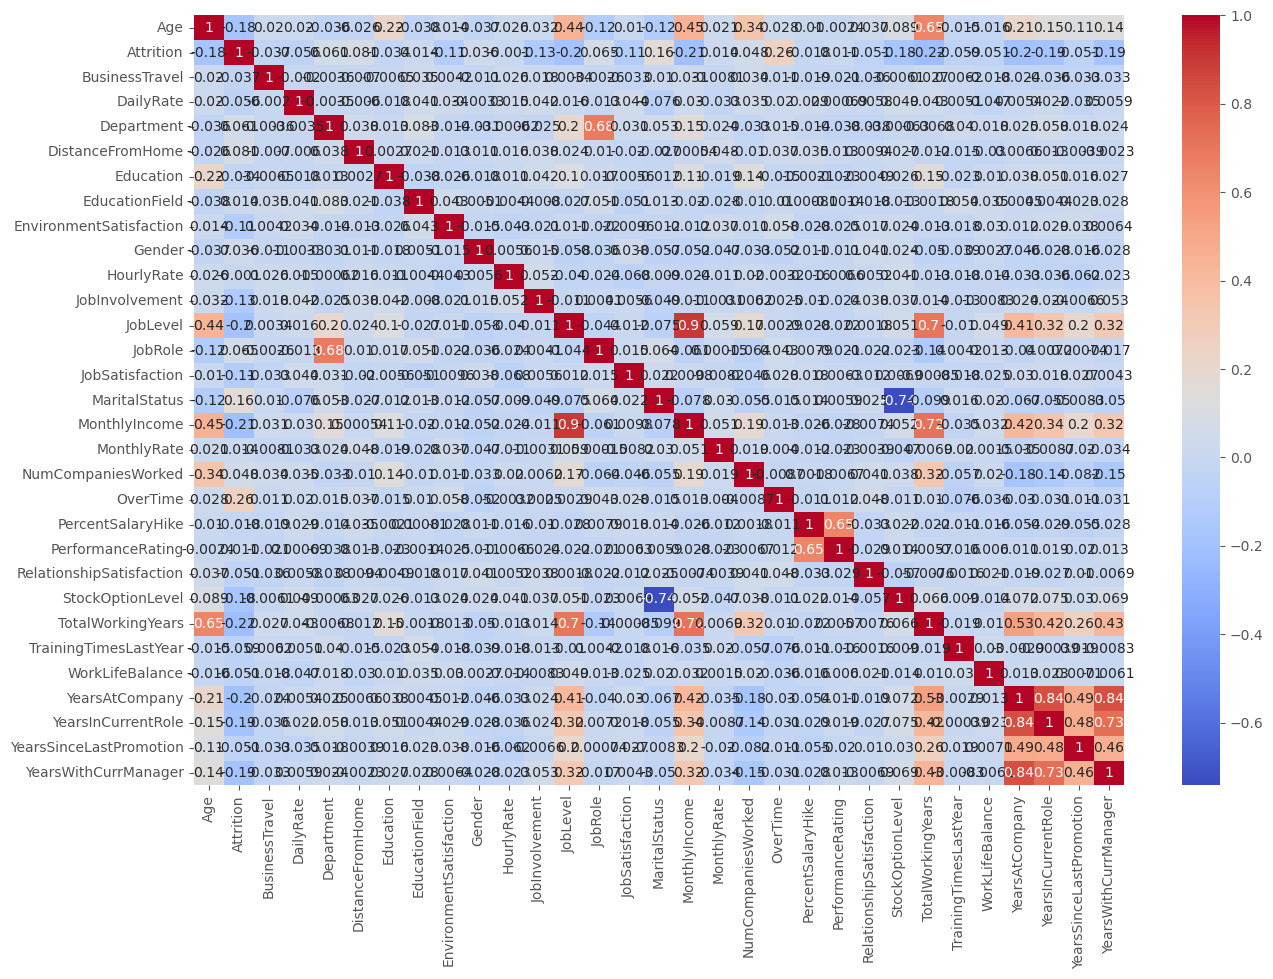

In [32]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

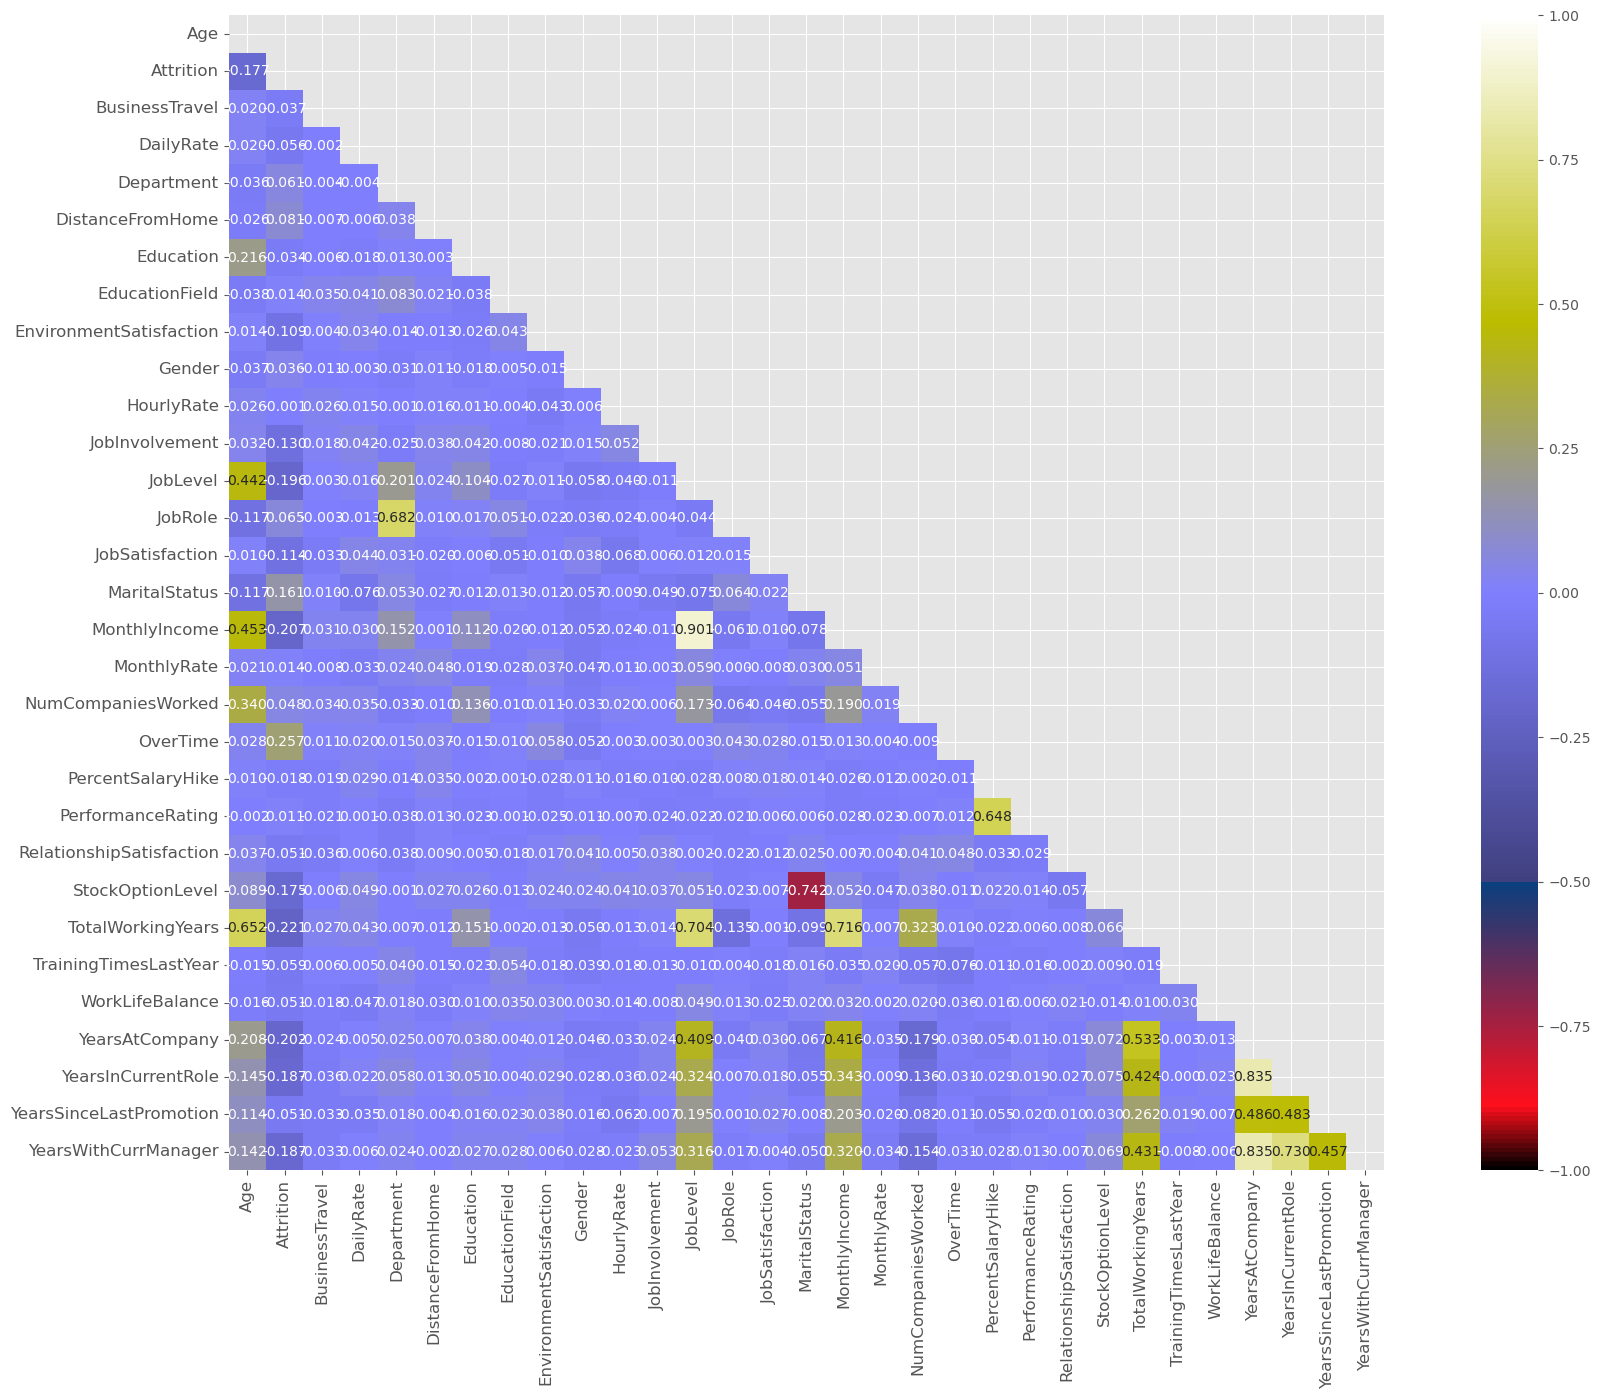

In [33]:
upper_triangle = np.triu(df.corr())
plt.figure(figsize=(25,15))
sns.heatmap(df.corr(), vmin=-1, vmax=1, annot=True, square=True, fmt='0.3f',
            annot_kws={'size':10}, cmap="gist_stern", mask=upper_triangle)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

- <b>Statistical Analysis


In [59]:
from scipy.stats import chi2_contingency, ttest_ind, f_oneway

- <b>Chi-Square Test

In [61]:
contingency_table = pd.crosstab(df['OverTime'], df['Attrition'])

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Statistic :", round(chi2,2))
print("P-value :", round(p,5))

if p < 0.05:
    print("Result : Significant relationship between OverTime and Attrition")
else:
    print("Result : No significant relationship")

Chi-Square Statistic : 87.56
P-value : 0.0
Result : Significant relationship between OverTime and Attrition


- <b>Independent T-Test

In [62]:
stay = df[df['Attrition']=='No']['MonthlyIncome']
leave = df[df['Attrition']=='Yes']['MonthlyIncome']

t_stat, p_value = ttest_ind(stay, leave)

print("\nT-Test Statistic :", round(t_stat,2))
print("P-value :", round(p_value,5))

if p_value < 0.05:
    print("Result : Monthly Income differs significantly.")
else:
    print("Result : No significant difference.")


T-Test Statistic : nan
P-value : nan
Result : No significant difference.


- <b> One-Way ANOVA

In [63]:
anova = f_oneway(
    df[df['Department']=='Sales']['MonthlyIncome'],
    df[df['Department']=='Research & Development']['MonthlyIncome'],
    df[df['Department']=='Human Resources']['MonthlyIncome']
)

print("\nANOVA Statistic :", round(anova.statistic,2))
print("P-value :", round(anova.pvalue,5))

if anova.pvalue < 0.05:
    print("Result : Monthly Income differs across Departments.")
else:
    print("Result : No significant difference across Departments.")


ANOVA Statistic : nan
P-value : nan
Result : No significant difference across Departments.


### 03 Machine Learning

In [34]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ( accuracy_score, classification_report, confusion_matrix)
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
import joblib

- <b> Encoding </b>

In [35]:
df = pd.read_csv("HR-Employee-Attrition.csv")
encoder = LabelEncoder()
for col in df.select_dtypes(include='object'):
    df[col] = encoder.fit_transform(df[col])

-  <b> Features </b>

In [36]:
X = df.drop( 'Attrition',axis=1)
y = df['Attrition']
print(X,y)

      Age  BusinessTravel  DailyRate  Department  DistanceFromHome  Education  \
0      41               2       1102           2                 1          2   
1      49               1        279           1                 8          1   
2      37               2       1373           1                 2          2   
3      33               1       1392           1                 3          4   
4      27               2        591           1                 2          1   
...   ...             ...        ...         ...               ...        ...   
1465   36               1        884           1                23          2   
1466   39               2        613           1                 6          1   
1467   27               2        155           1                 4          3   
1468   49               1       1023           2                 2          3   
1469   34               2        628           1                 8          3   

      EducationField  Emplo

-  <b>Train Test Split</b>

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
X_train, X_test, y_train, y_test

(      Age  BusinessTravel  DailyRate  Department  DistanceFromHome  Education  \
 1097   24               2        350           1                21          2   
 727    18               0        287           1                 5          2   
 254    29               2       1247           2                20          2   
 1175   39               2        492           1                12          3   
 1341   31               2        311           1                20          3   
 ...   ...             ...        ...         ...               ...        ...   
 1130   35               2        750           1                28          3   
 1294   41               2        447           1                 5          3   
 860    22               1       1256           1                 3          4   
 1459   29               2       1378           1                13          2   
 1126   50               2        264           2                 9          3   
 
       Educati

- <b>Feature Selection using Mutual Information

In [64]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

mi_scores = mutual_info_classif(X_train, y_train, random_state=42)

mi_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Mutual Information Score': mi_scores
})

mi_df = mi_df.sort_values(by='Mutual Information Score', ascending=False)

print("Top Features based on Mutual Information:\n")
print(mi_df.head(10))

Top Features based on Mutual Information:

              Feature  Mutual Information Score
21           OverTime                  0.058207
17      MonthlyIncome                  0.042077
27  TotalWorkingYears                  0.034995
13           JobLevel                  0.032723
0                 Age                  0.031295
15    JobSatisfaction                  0.026995
16      MaritalStatus                  0.025238
1      BusinessTravel                  0.023537
4    DistanceFromHome                  0.020871
7       EmployeeCount                  0.019620


- <b>Recursive Feature Elimination (RFE)

In [65]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

rfe = RFE(estimator=lr, n_features_to_select=10)

rfe.fit(X_train, y_train)

rfe_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Selected': rfe.support_,
    'Ranking': rfe.ranking_
})

print("Top Features Selected by RFE:\n")
print(rfe_df.sort_values('Ranking').head(15))

Top Features Selected by RFE:

                     Feature  Selected  Ranking
16             MaritalStatus      True        1
29           WorkLifeBalance      True        1
3                 Department      True        1
26          StockOptionLevel      True        1
21                  OverTime      True        1
9    EnvironmentSatisfaction      True        1
10                    Gender      True        1
12            JobInvolvement      True        1
13                  JobLevel      True        1
15           JobSatisfaction      True        1
23         PerformanceRating     False        2
31        YearsInCurrentRole     False        3
32   YearsSinceLastPromotion     False        4
24  RelationshipSatisfaction     False        5
19        NumCompaniesWorked     False        6


-  <b>Random Forest </b>

In [38]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train, y_train)


,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


-  <b> Prediction</b>

In [39]:
predictions = rf.predict(X_test)
predictions

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0])

-  <b>Evaluation</b>

In [40]:
print( "Accuracy:", accuracy_score(y_test, predictions))

print(classification_report(y_test, predictions))

Accuracy: 0.8741496598639455
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       255
           1       0.67      0.10      0.18        39

    accuracy                           0.87       294
   macro avg       0.77      0.55      0.55       294
weighted avg       0.85      0.87      0.83       294



-  <b> Confusion Matrix</b>

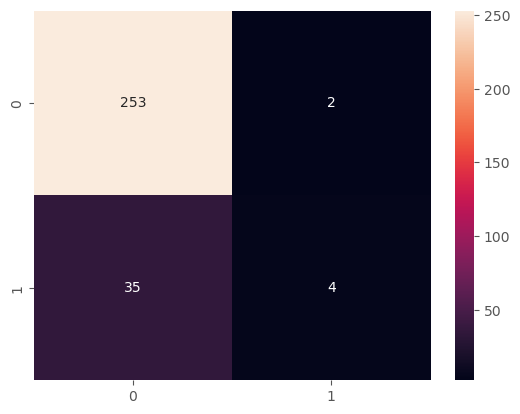

In [41]:
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

- <b>Logistic Regression Model</b>

In [42]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.8707482993197279


- <b>Decision Tree</b>

In [43]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.7993197278911565


-  <b> Feature Importance <b>

In [45]:
importance = pd.DataFrame({"Feature": X.columns, "Importance": rf.feature_importances_})
importance = importance.sort_values(by="Importance", ascending=False)
print(importance.head(10))

              Feature  Importance
17      MonthlyIncome    0.081941
21           OverTime    0.069893
0                 Age    0.054518
27  TotalWorkingYears    0.049714
2           DailyRate    0.049365
8      EmployeeNumber    0.046414
18        MonthlyRate    0.045532
11         HourlyRate    0.042313
30     YearsAtCompany    0.041903
4    DistanceFromHome    0.038635


- <b>ROC AUC Score</b>

In [46]:
rf_prob = rf.predict_proba(X_test)[:,1]
roc_score = roc_auc_score(
    y_test,
    rf_prob
)
print("ROC AUC Score:",
      roc_score)

ROC AUC Score: 0.7326294620412267


- <b>ROC Curve</b>

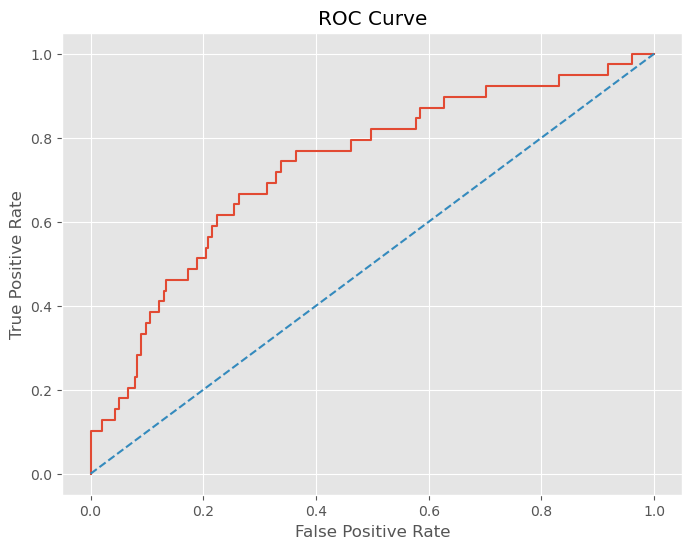

In [47]:
fpr, tpr, thresholds = roc_curve(y_test, rf_prob)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

- <b>Learning Curve (Professional ML Evaluation)

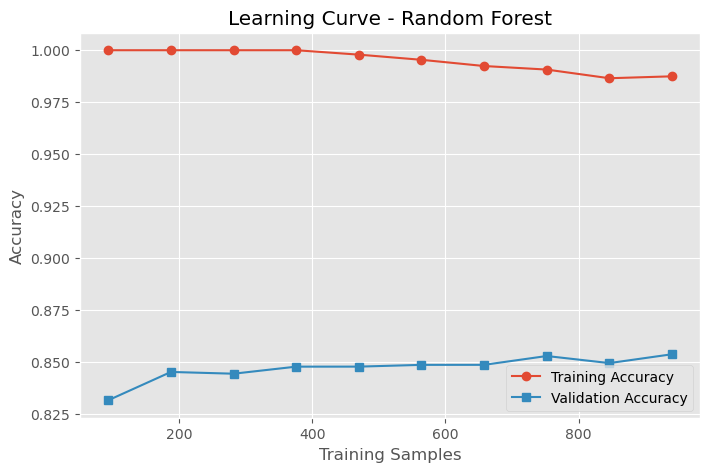

In [80]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    estimator=rf,
    X=X_train,
    y=y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=42
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, marker='o', label='Training Accuracy')
plt.plot(train_sizes, test_mean, marker='s', label='Validation Accuracy')

plt.title("Learning Curve - Random Forest")
plt.xlabel("Training Samples")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

- <b>Cross Validation</b>

In [48]:
scores = cross_val_score(rf, X, y, cv=5)

print("Cross Validation Scores:")
print(scores)
print("Average CV Score:")
print(scores.mean())

Cross Validation Scores:
[0.84693878 0.86734694 0.86734694 0.85714286 0.8537415 ]
Average CV Score:
0.8585034013605443


- <b>Gradient Boosting Classifier

In [66]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

print("Gradient Boosting Accuracy :", round(accuracy_score(y_test, gb_pred)*100,2),"%")

print("\nClassification Report:\n")
print(classification_report(y_test, gb_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, gb_pred))

Gradient Boosting Accuracy : 88.78 %

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.97      0.94       255
           1       0.65      0.33      0.44        39

    accuracy                           0.89       294
   macro avg       0.78      0.65      0.69       294
weighted avg       0.87      0.89      0.87       294


Confusion Matrix:

[[248   7]
 [ 26  13]]


- <b> K-Nearest Neighbors (KNN)

In [67]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

print("KNN Accuracy :", round(accuracy_score(y_test, knn_pred)*100,2),"%")

print("\nClassification Report:\n")
print(classification_report(y_test, knn_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, knn_pred))

KNN Accuracy : 85.37 %

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.96      0.92       255
           1       0.36      0.13      0.19        39

    accuracy                           0.85       294
   macro avg       0.62      0.55      0.55       294
weighted avg       0.81      0.85      0.82       294


Confusion Matrix:

[[246   9]
 [ 34   5]]


- <b>Model Comparison

In [74]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "KNN"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, predictions),
        accuracy_score(y_test, gb_pred),
        accuracy_score(y_test, knn_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, predictions),
        precision_score(y_test, gb_pred),
        precision_score(y_test, knn_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, predictions),
        recall_score(y_test, gb_pred),
        recall_score(y_test, knn_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, predictions),
        f1_score(y_test, gb_pred),
        f1_score(y_test, knn_pred)
    ]
})

comparison = comparison.sort_values(by="Accuracy", ascending=False)

print(comparison)

                 Model  Accuracy  Precision    Recall  F1 Score
3    Gradient Boosting  0.887755   0.650000  0.333333  0.440678
2        Random Forest  0.874150   0.666667  0.102564  0.177778
0  Logistic Regression  0.870748   0.545455  0.153846  0.240000
4                  KNN  0.853741   0.357143  0.128205  0.188679
1        Decision Tree  0.799320   0.205882  0.179487  0.191781


- <b>Hyperparameter Tuning</b>

In [49]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators':[100,200,300],
    'max_depth':[5,10,15]
}
grid = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv=5
)

grid.fit(X_train, y_train)

print("Best Parameters:")

print(grid.best_params_)

Best Parameters:
{'max_depth': 10, 'n_estimators': 300}


- <b>Feature Importance</b>

In [50]:
feature_importance = pd.DataFrame({'Feature':X.columns, 'Importance':rf.feature_importances_})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print(feature_importance.head(10))

              Feature  Importance
17      MonthlyIncome    0.081941
21           OverTime    0.069893
0                 Age    0.054518
27  TotalWorkingYears    0.049714
2           DailyRate    0.049365
8      EmployeeNumber    0.046414
18        MonthlyRate    0.045532
11         HourlyRate    0.042313
30     YearsAtCompany    0.041903
4    DistanceFromHome    0.038635


- <b>Feature Importance Chart</b>

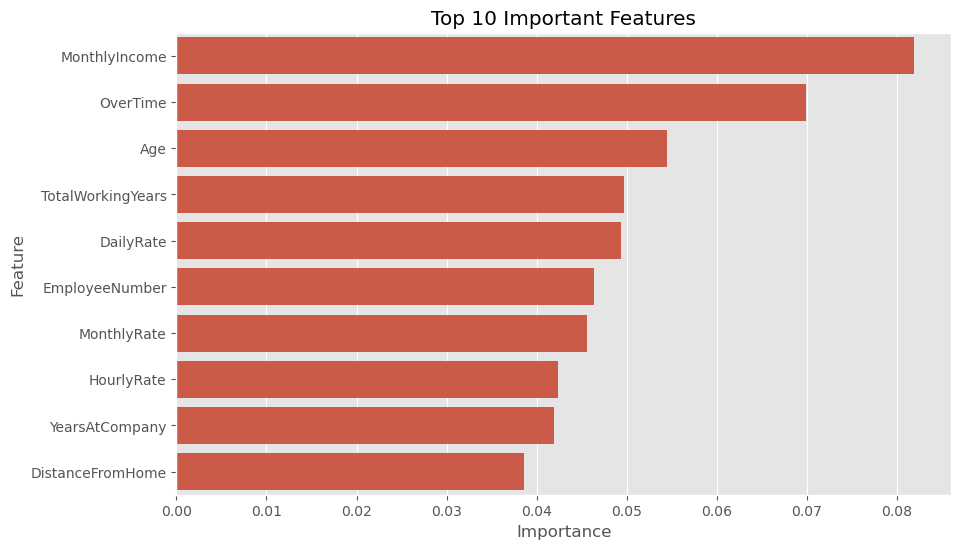

In [51]:
plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance.head(10), x='Importance', y='Feature')

plt.title('Top 10 Important Features')
plt.show()

- <b> Save Model</b>

In [52]:
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [53]:
import os
import joblib

os.makedirs("models", exist_ok=True)
joblib.dump(rf, "models/attrition_model.pkl")
print("Model saved successfully!")

Model saved successfully!
